<a href="https://colab.research.google.com/github/manavsharma111/Machine-Learning/blob/main/House_price.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
# import sheryanalysis as sys
warnings.filterwarnings('ignore')

In [12]:
df=pd.read_csv('Housing.csv')

In [13]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [14]:
df.shape

(545, 13)

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [16]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [17]:
df.isnull().sum()

,0
price,0
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0
airconditioning,0


EDA

<Axes: xlabel='price', ylabel='Count'>

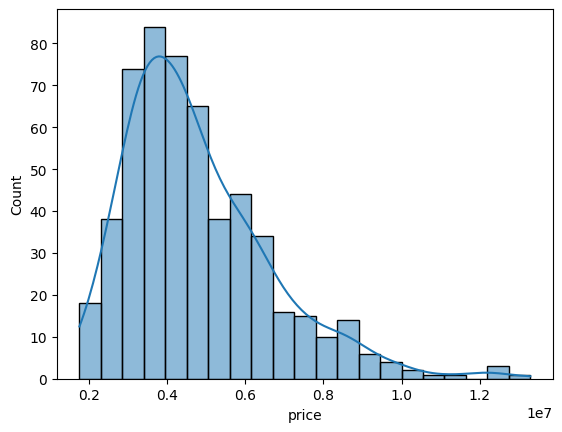

In [18]:
sns.histplot(df['price'], kde=True)

In [19]:
from pandas.core.arrays import numeric
df.corr(numeric_only=True)

,price,area,bedrooms,bathrooms,stories,parking
price,1.000000,0.535997,0.366494,0.517545,0.420712,0.384394
area,0.535997,1.000000,0.151858,0.193820,0.083996,0.352980
bedrooms,0.366494,0.151858,1.000000,0.373930,0.408564,0.139270
bathrooms,0.517545,0.193820,0.373930,1.000000,0.326165,0.177496
stories,0.420712,0.083996,0.408564,0.326165,1.000000,0.045547
parking,0.384394,0.352980,0.139270,0.177496,0.045547,1.000000


<Axes: >

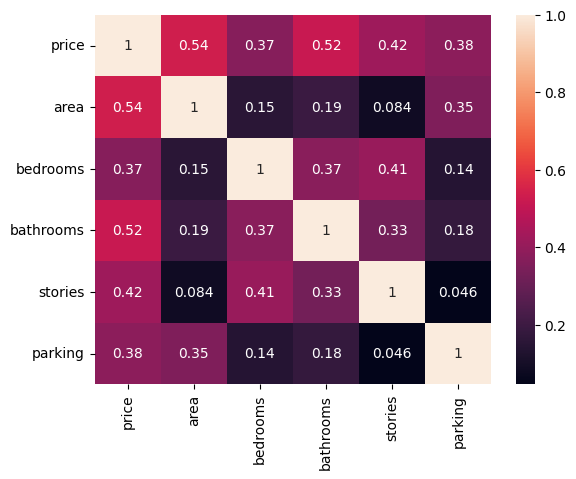

In [20]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

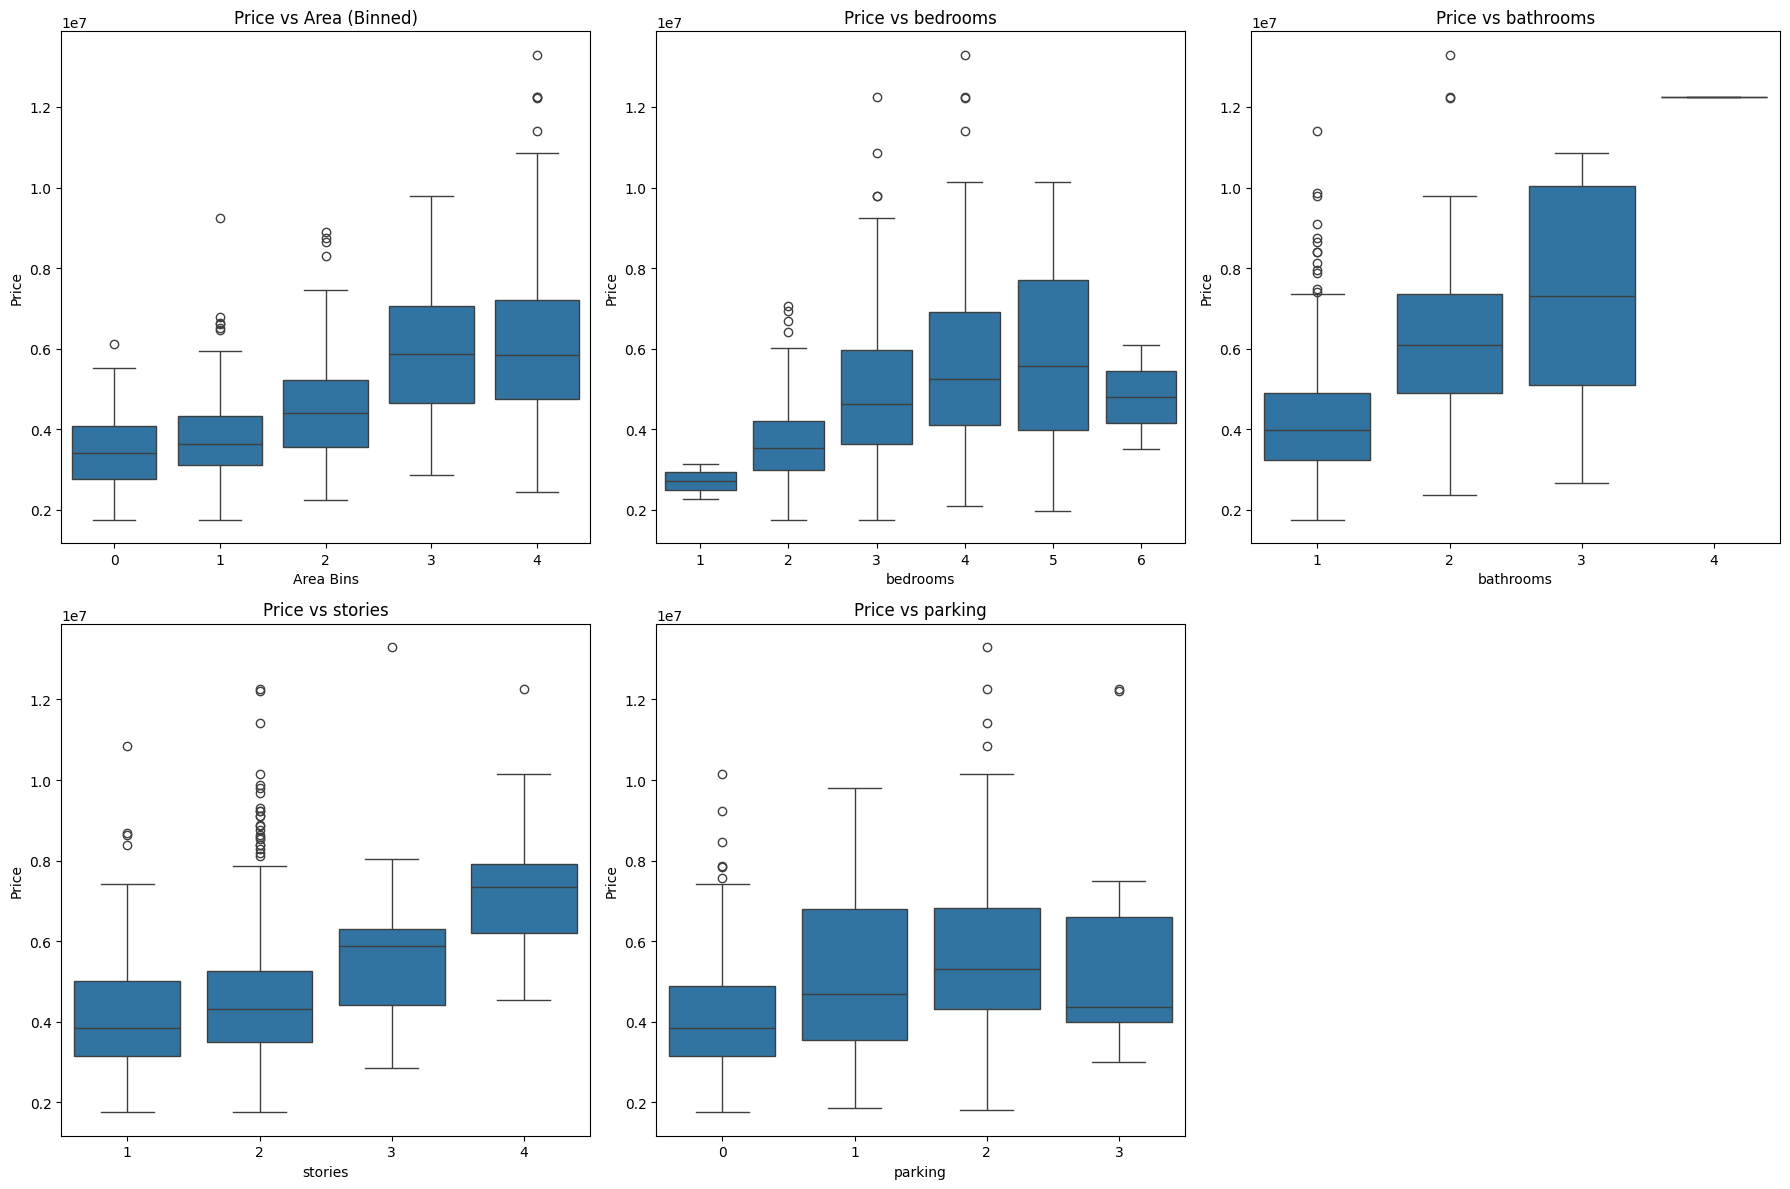

In [21]:
numerical_cols_for_boxplot = ['area', 'bedrooms', 'bathrooms', 'stories', 'parking']

plt.figure(figsize=(18, 12))

for i, col in enumerate(numerical_cols_for_boxplot):
    plt.subplot(2, 3, i + 1) # Adjust subplot grid as needed
    if col == 'area':
        # For 'area', discretize into bins for better box plot visualization
        # Use qcut to create approximately equal-sized bins based on quantiles
        df_temp = df.copy()
        df_temp['area_bins'] = pd.qcut(df_temp['area'], q=5, labels=False, duplicates='drop')
        sns.boxplot(x='area_bins', y='price', data=df_temp)
        plt.title(f'Price vs Area (Binned)')
        plt.xlabel('Area Bins')
    else:
        # For other numerical columns with limited unique values, plot directly
        sns.boxplot(x=col, y='price', data=df)
        plt.title(f'Price vs {col}')
        plt.xlabel(col)
    plt.ylabel('Price')

plt.tight_layout()
plt.show()

In [22]:
from sklearn.model_selection import train_test_split

# Define target variable
y = df['price']

# Prepare features (X)
# Convert binary categorical variables ('yes'/'no') to 1/0
binary_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']
for col in binary_cols:
    df[col] = df[col].apply(lambda x: 1 if x == 'yes' else 0)

# One-hot encode 'furnishingstatus'
df = pd.get_dummies(df, columns=['furnishingstatus'], drop_first=True)

# Drop the original 'price' column from features, as it's our target
X = df.drop('price', axis=1)

# Display the first few rows of the processed features and target
print("Features (X) head:")
display(X.head())
print("\nTarget (y) head:")
display(y.head())

Features (X) head:


,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,7420,4,2,3,1,0,0,0,1,2,1,False,False
1,8960,4,4,4,1,0,0,0,1,3,0,False,False
2,9960,3,2,2,1,0,1,0,0,2,1,True,False
3,7500,4,2,2,1,0,1,0,1,3,1,False,False
4,7420,4,1,2,1,1,1,0,1,2,0,False,False



Target (y) head:


,price
0,13300000
1,12250000
2,12250000
3,12215000
4,11410000


In [23]:
# Split the data into training and testing sets
# Using a 70/30 split and a random_state for reproducibility
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (381, 13)
X_test shape: (164, 13)
y_train shape: (381,)
y_test shape: (164,)


In [24]:
from sklearn.linear_model import LinearRegression

# Initialize the Linear Regression model
model = LinearRegression()

# Train the model on the training data
model.fit(X_train, y_train)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [25]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Make predictions on the test set
y_pred = model.predict(X_test)

# Calculate evaluation metrics
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"Model Performance on Test Set:")
print(f"R-squared (R2): {r2:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")

Model Performance on Test Set:
R-squared (R2): 0.6463
Mean Absolute Error (MAE): 920392.94
Mean Squared Error (MSE): 1523019469501.29
Root Mean Squared Error (RMSE): 1234106.75


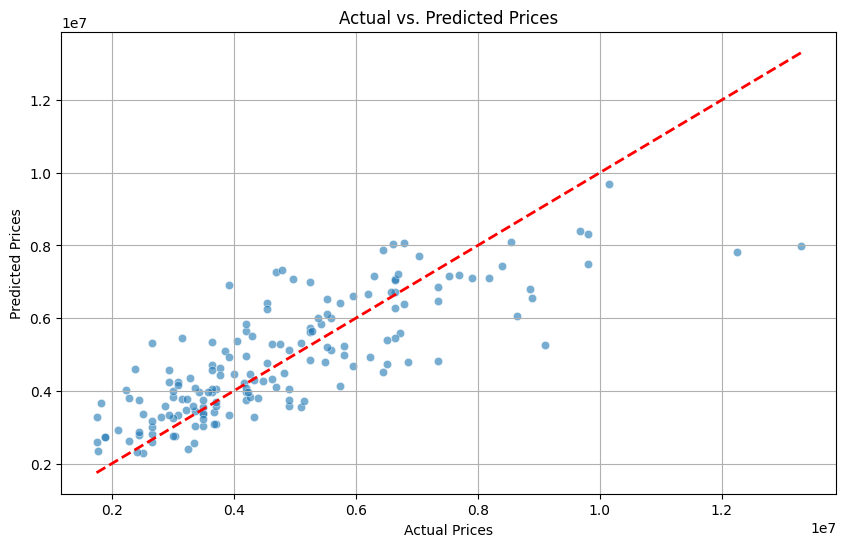

In [26]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Diagonal line for perfect prediction
plt.title('Actual vs. Predicted Prices')
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.grid(True)
plt.show()

In [27]:
from sklearn.preprocessing import StandardScaler

# Identify numerical columns to scale (excluding the binary/one-hot encoded ones)
# 'price' is the target, so it's not in X
numerical_cols = ['area', 'bedrooms', 'bathrooms', 'stories', 'parking']

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit the scaler only on the training data's numerical columns
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test_scaled[numerical_cols] = scaler.transform(X_test[numerical_cols])

print("Numerical features in X_train and X_test have been scaled.")
display(X_train_scaled.head())
display(X_test_scaled.head())

Numerical features in X_train and X_test have been scaled.


,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
126,0.934301,0.055861,-0.553238,-0.907660,1,0,1,0,0,1.591603,1,False,True
363,-0.710246,-1.274325,-0.553238,-0.907660,1,0,0,1,0,-0.800511,0,True,False
370,-0.390167,-1.274325,-0.553238,-0.907660,1,0,0,0,1,1.591603,0,True,False
31,0.860719,0.055861,-0.553238,2.573733,1,0,0,0,1,1.591603,0,True,False
113,2.065617,0.055861,-0.553238,-0.907660,1,0,1,0,0,1.591603,1,False,False


,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
316,0.354846,1.386046,1.554599,0.252805,0,0,1,0,0,0.395546,0,False,True
77,0.630777,0.055861,1.554599,1.413269,1,0,0,0,1,-0.800511,1,False,False
360,-0.500539,-1.274325,-0.553238,-0.907660,1,0,0,0,0,-0.800511,0,True,False
90,-0.059050,0.055861,-0.553238,0.252805,1,0,0,0,1,-0.800511,0,True,False
493,-0.537330,0.055861,-0.553238,-0.907660,1,0,0,0,0,-0.800511,0,False,False


In [28]:
from sklearn.linear_model import LinearRegression

# Initialize a new Linear Regression model
scaled_model = LinearRegression()

# Train the model on the scaled training data
scaled_model.fit(X_train_scaled, y_train)

print("Linear Regression model re-trained successfully with scaled features!")

Linear Regression model re-trained successfully with scaled features!


In [29]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Make predictions on the scaled test set
y_pred_scaled = scaled_model.predict(X_test_scaled)

# Calculate evaluation metrics for the scaled model
r2_scaled = r2_score(y_test, y_pred_scaled)
mae_scaled = mean_absolute_error(y_test, y_pred_scaled)
mse_scaled = mean_squared_error(y_test, y_pred_scaled)
rmse_scaled = np.sqrt(mse_scaled)

print(f"\nModel Performance with Scaled Features on Test Set:")
print(f"R-squared (R2): {r2_scaled:.4f}")
print(f"Mean Absolute Error (MAE): {mae_scaled:.2f}")
print(f"Mean Squared Error (MSE): {mse_scaled:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_scaled:.2f}")

print(f"\nOriginal Model Performance:")
print(f"R-squared (R2): {r2:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")


Model Performance with Scaled Features on Test Set:
R-squared (R2): 0.6463
Mean Absolute Error (MAE): 920392.94
Mean Squared Error (MSE): 1523019469501.29
Root Mean Squared Error (RMSE): 1234106.75

Original Model Performance:
R-squared (R2): 0.6463
Mean Absolute Error (MAE): 920392.94
Mean Squared Error (MSE): 1523019469501.29
Root Mean Squared Error (RMSE): 1234106.75


### Logistic Regression

In [37]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Ensure df is available. Assuming it's already loaded or will be reloaded.
# If df is not defined, reload it (assuming Housing.csv exists)
df = pd.read_csv('Housing.csv')

# Re-process features as done previously (if df was modified in prior cells)
df_temp = df.copy() # Use a temporary copy to avoid modifying the original df for each model cell
binary_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']
for col in binary_cols:
    if col in df_temp.columns:
        df_temp[col] = df_temp[col].apply(lambda x: 1 if x == 'yes' else 0)

df_processed = pd.get_dummies(df_temp, columns=['furnishingstatus'], drop_first=True)

y_model = df_processed['price'] # Renamed to avoid conflicts if y is used by other models
X_model = df_processed.drop('price', axis=1) # Renamed to avoid conflicts

X_train_model, X_test_model, y_train_model, y_test_model = train_test_split(X_model, y_model, test_size=0.3, random_state=42)

numerical_cols = ['area', 'bedrooms', 'bathrooms', 'stories', 'parking']
scaler = StandardScaler()
X_train_scaled_model = X_train_model.copy()
X_test_scaled_model = X_test_model.copy()
X_train_scaled_model[numerical_cols] = scaler.fit_transform(X_train_model[numerical_cols])
X_test_scaled_model[numerical_cols] = scaler.transform(X_test_model[numerical_cols])


# As a workaround for demonstrating, let's make it a binary classification problem for Logistic Regression
# For simplicity, let's classify if price is above or below median.
median_price = y_train_model.median()
y_train_binary = (y_train_model > median_price).astype(int)
y_test_binary = (y_test_model > median_price).astype(int)

log_reg_model = LogisticRegression(random_state=42, solver='liblinear') # Using 'liblinear' solver for small datasets

# Train the model
log_reg_model.fit(X_train_scaled_model, y_train_binary)

# Make predictions on the test set
y_pred_log_reg = log_reg_model.predict(X_test_scaled_model)

# Evaluate the model (for classification, we'd use accuracy, precision, recall, f1-score)
accuracy_log_reg = accuracy_score(y_test_binary, y_pred_log_reg)
precision_log_reg = precision_score(y_test_binary, y_pred_log_reg)
recall_log_reg = recall_score(y_test_binary, y_pred_log_reg)
f1_log_reg = f1_score(y_test_binary, y_pred_log_reg)

print(f"Logistic Regression Model Performance (Binary Classification):")
print(f"Accuracy: {accuracy_log_reg:.4f}")
print(f"Precision: {precision_log_reg:.4f}")
print(f"Recall: {recall_log_reg:.4f}")
print(f"F1-Score: {f1_log_reg:.4f}")

# Note: If the intention was regression, Logistic Regression is not the right model for continuous 'price'.
# I've adapted it to a binary classification problem for demonstration purposes.

Logistic Regression Model Performance (Binary Classification):
Accuracy: 0.8171
Precision: 0.8077
Recall: 0.8077
F1-Score: 0.8077


### K-Nearest Neighbors (KNN)

In [49]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

# Ensure df is available. Assuming it's already loaded or will be reloaded.
# If df is not defined, reload it (assuming Housing.csv exists)
df = pd.read_csv('Housing.csv')

# Re-process features as done previously (if df was modified in prior cells)
df_temp = df.copy() # Use a temporary copy to avoid modifying the original df for each model cell
binary_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']
for col in binary_cols:
    if col in df_temp.columns:
        df_temp[col] = df_temp[col].apply(lambda x: 1 if x == 'yes' else 0)

df_processed = pd.get_dummies(df_temp, columns=['furnishingstatus'], drop_first=True)

y_model = df_processed['price'] # Renamed to avoid conflicts
X_model = df_processed.drop('price', axis=1) # Renamed to avoid conflicts

X_train_model, X_test_model, y_train_model, y_test_model = train_test_split(X_model, y_model, test_size=0.3, random_state=42)

numerical_cols = ['area', 'bedrooms', 'bathrooms', 'stories', 'parking']
scaler = StandardScaler()
X_train_scaled_model = X_train_model.copy()
X_test_scaled_model = X_test_model.copy()
X_train_scaled_model[numerical_cols] = scaler.fit_transform(X_train_model[numerical_cols])
X_test_scaled_model[numerical_cols] = scaler.transform(X_test_model[numerical_cols])

# Initialize KNN Regressor model
knn_model = KNeighborsRegressor(n_neighbors=5) # You can adjust n_neighbors

# Train the model
knn_model.fit(X_train_scaled_model, y_train_model)

# Make predictions on the test set
y_pred_knn = knn_model.predict(X_test_scaled_model)

# Calculate evaluation metrics
r2_knn = r2_score(y_test_model, y_pred_knn)
mae_knn = mean_absolute_error(y_test_model, y_pred_knn)
mse_knn = mean_squared_error(y_test_model, y_pred_knn)
rmse_knn = np.sqrt(mse_knn)

print(f"K-Nearest Neighbors (KNN) Model Performance on Test Set:")
print(f"R-squared (R2): {r2_knn:.4f}")
print(f"Mean Absolute Error (MAE): {mae_knn:.2f}")
print(f"Mean Squared Error (MSE): {mse_knn:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_knn:.2f}")

K-Nearest Neighbors (KNN) Model Performance on Test Set:
R-squared (R2): 0.5797
Mean Absolute Error (MAE): 962270.79
Mean Squared Error (MSE): 1809856335839.49
Root Mean Squared Error (RMSE): 1345309.01


### Support Vector Machine (SVM) - SVR for Regression

In [39]:
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

# Ensure df is available. Assuming it's already loaded or will be reloaded.
# If df is not defined, reload it (assuming Housing.csv exists)
df = pd.read_csv('Housing.csv')

# Re-process features as done previously (if df was modified in prior cells)
df_temp = df.copy() # Use a temporary copy to avoid modifying the original df for each model cell
binary_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']
for col in binary_cols:
    if col in df_temp.columns:
        df_temp[col] = df_temp[col].apply(lambda x: 1 if x == 'yes' else 0)

df_processed = pd.get_dummies(df_temp, columns=['furnishingstatus'], drop_first=True)

y_model = df_processed['price'] # Renamed to avoid conflicts
X_model = df_processed.drop('price', axis=1) # Renamed to avoid conflicts

X_train_model, X_test_model, y_train_model, y_test_model = train_test_split(X_model, y_model, test_size=0.3, random_state=42)

numerical_cols = ['area', 'bedrooms', 'bathrooms', 'stories', 'parking']
scaler = StandardScaler()
X_train_scaled_model = X_train_model.copy()
X_test_scaled_model = X_test_model.copy()
X_train_scaled_model[numerical_cols] = scaler.fit_transform(X_train_model[numerical_cols])
X_test_scaled_model[numerical_cols] = scaler.transform(X_test_model[numerical_cols])

# Initialize SVR model
svr_model = SVR(kernel='linear') # You can experiment with different kernels like 'rbf', 'poly'

# Train the model
svr_model.fit(X_train_scaled_model, y_train_model)

# Make predictions on the test set
y_pred_svr = svr_model.predict(X_test_scaled_model)

# Calculate evaluation metrics
r2_svr = r2_score(y_test_model, y_pred_svr)
mae_svr = mean_absolute_error(y_test_model, y_pred_svr)
mse_svr = mean_squared_error(y_test_model, y_pred_svr)
rmse_svr = np.sqrt(mse_svr)

print(f"Support Vector Regressor (SVR) Model Performance on Test Set:")
print(f"R-squared (R2): {r2_svr:.4f}")
print(f"Mean Absolute Error (MAE): {mae_svr:.2f}")
print(f"Mean Squared Error (MSE): {mse_svr:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_svr:.2f}")

Support Vector Regressor (SVR) Model Performance on Test Set:
R-squared (R2): -0.0359
Mean Absolute Error (MAE): 1577820.04
Mean Squared Error (MSE): 4460831414182.47
Root Mean Squared Error (RMSE): 2112068.04


### Decision Tree Regressor

In [40]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

# Ensure df is available. Assuming it's already loaded or will be reloaded.
# If df is not defined, reload it (assuming Housing.csv exists)
df = pd.read_csv('Housing.csv')

# Re-process features as done previously (if df was modified in prior cells)
df_temp = df.copy() # Use a temporary copy to avoid modifying the original df for each model cell
binary_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']
for col in binary_cols:
    if col in df_temp.columns:
        df_temp[col] = df_temp[col].apply(lambda x: 1 if x == 'yes' else 0)

df_processed = pd.get_dummies(df_temp, columns=['furnishingstatus'], drop_first=True)

y_model = df_processed['price'] # Renamed to avoid conflicts
X_model = df_processed.drop('price', axis=1) # Renamed to avoid conflicts

X_train_model, X_test_model, y_train_model, y_test_model = train_test_split(X_model, y_model, test_size=0.3, random_state=42)

numerical_cols = ['area', 'bedrooms', 'bathrooms', 'stories', 'parking']
scaler = StandardScaler()
X_train_scaled_model = X_train_model.copy()
X_test_scaled_model = X_test_model.copy()
X_train_scaled_model[numerical_cols] = scaler.fit_transform(X_train_model[numerical_cols])
X_test_scaled_model[numerical_cols] = scaler.transform(X_test_model[numerical_cols])

# Initialize Decision Tree Regressor model
dt_model = DecisionTreeRegressor(random_state=42)

# Train the model
dt_model.fit(X_train_scaled_model, y_train_model)

# Make predictions on the test set
y_pred_dt = dt_model.predict(X_test_scaled_model)

# Calculate evaluation metrics
r2_dt = r2_score(y_test_model, y_pred_dt)
mae_dt = mean_absolute_error(y_test_model, y_pred_dt)
mse_dt = mean_squared_error(y_test_model, y_pred_dt)
rmse_dt = np.sqrt(mse_dt)

print(f"Decision Tree Regressor Model Performance on Test Set:")
print(f"R-squared (R2): {r2_dt:.4f}")
print(f"Mean Absolute Error (MAE): {mae_dt:.2f}")
print(f"Mean Squared Error (MSE): {mse_dt:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_dt:.2f}")

Decision Tree Regressor Model Performance on Test Set:
R-squared (R2): 0.1845
Mean Absolute Error (MAE): 1240065.79
Mean Squared Error (MSE): 3511922185403.05
Root Mean Squared Error (RMSE): 1874012.32


### Model Performance Summary

In [41]:

model_performance = {
    'Linear Regression': {
        'R-squared (R2)': r2_scaled, # Using scaled model's R2
        'MAE': mae_scaled,
        'MSE': mse_scaled,
        'RMSE': rmse_scaled
    },
    'Logistic Regression': {
        'Accuracy': accuracy_log_reg,
        'Precision': precision_log_reg,
        'Recall': recall_log_reg,
        'F1-Score': f1_log_reg
    },
    'K-Nearest Neighbors (KNN) Regressor': {
        'R-squared (R2)': r2_knn,
        'MAE': mae_knn,
        'MSE': mse_knn,
        'RMSE': rmse_knn
    },
    'Support Vector Regressor (SVR)': {
        'R-squared (R2)': r2_svr,
        'MAE': mae_svr,
        'MSE': mse_svr,
        'RMSE': rmse_svr
    },
    'Decision Tree Regressor': {
        'R-squared (R2)': r2_dt,
        'MAE': mae_dt,
        'MSE': mse_dt,
        'RMSE': rmse_dt
    }
}


for model_name, metrics in model_performance.items():
    print(f"\n{model_name}:")
    for metric, value in metrics.items():
        print(f"  {metric}: {value:.4f}")



Linear Regression:
  R-squared (R2): 0.6463
  MAE: 920392.9398
  MSE: 1523019469501.2915
  RMSE: 1234106.7496

Logistic Regression:
  Accuracy: 0.8171
  Precision: 0.8077
  Recall: 0.8077
  F1-Score: 0.8077

K-Nearest Neighbors (KNN) Regressor:
  R-squared (R2): 0.5797
  MAE: 962270.7927
  MSE: 1809856335839.4878
  RMSE: 1345309.0113

Support Vector Regressor (SVR):
  R-squared (R2): -0.0359
  MAE: 1577820.0359
  MSE: 4460831414182.4697
  RMSE: 2112068.0420

Decision Tree Regressor:
  R-squared (R2): 0.1845
  MAE: 1240065.7927
  MSE: 3511922185403.0488
  RMSE: 1874012.3226


In [ ]:
# compare performance

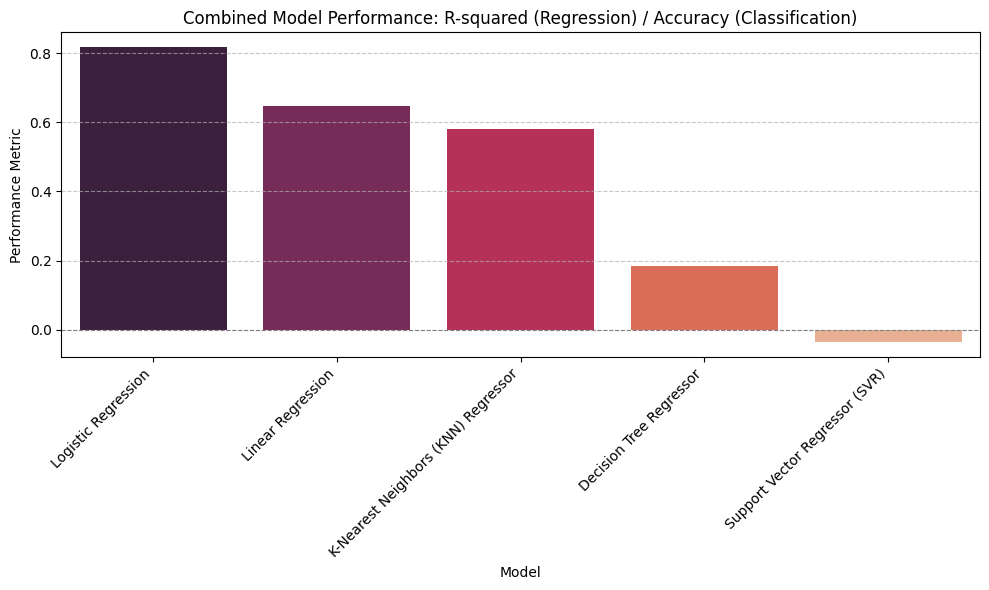

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Create a dictionary to hold the primary performance metric for each model
combined_performance = {}

for model_name, metrics in model_performance.items():
    if 'R-squared (R2)' in metrics: # For regression models
        combined_performance[model_name] = metrics['R-squared (R2)']
    elif 'Accuracy' in metrics: # For classification model
        combined_performance[model_name] = metrics['Accuracy']

# Convert the dictionary to a DataFrame
df_combined_performance = pd.DataFrame.from_dict(combined_performance, orient='index', columns=['Performance'])

# Sort for better visualization (higher is generally better for R2 and Accuracy)
df_combined_performance = df_combined_performance.sort_values(by='Performance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=df_combined_performance.index, y='Performance', data=df_combined_performance, palette='rocket')

plt.title('Combined Model Performance: R-squared (Regression) / Accuracy (Classification)')
plt.xlabel('Model')
plt.ylabel('Performance Metric')
plt.xticks(rotation=45, ha='right')
plt.axhline(0, color='grey', linestyle='--', linewidth=0.8) # Add a line at 0 for context
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [46]:
for model_name, metrics in model_performance.items():
    print(f"\n{model_name}:")
    for metric, value in metrics.items():
        print(f"  {metric}: {value:.4f}")


Linear Regression:
  R-squared (R2): 0.6463
  MAE: 920392.9398
  MSE: 1523019469501.2915
  RMSE: 1234106.7496

Logistic Regression:
  Accuracy: 0.8171
  Precision: 0.8077
  Recall: 0.8077
  F1-Score: 0.8077

K-Nearest Neighbors (KNN) Regressor:
  R-squared (R2): 0.5797
  MAE: 962270.7927
  MSE: 1809856335839.4878
  RMSE: 1345309.0113

Support Vector Regressor (SVR):
  R-squared (R2): -0.0359
  MAE: 1577820.0359
  MSE: 4460831414182.4697
  RMSE: 2112068.0420

Decision Tree Regressor:
  R-squared (R2): 0.1845
  MAE: 1240065.7927
  MSE: 3511922185403.0488
  RMSE: 1874012.3226


In [51]:
import joblib
joblib.dump(model, 'linear_regression_model.joblib')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(X.columns.tolist(),'columns.pkl')


['columns.pkl']